# Automated Detection of Teams of Players using IPL Jersey Identification
### Programming for Machine Learning and Data Science — Course Project (CMInDS, IIT Bombay)

Given an 800×600 cricket image, divide it into an **8×8 grid (64 cells)** and predict a label `0–10` for every cell (IPL franchise occupying that cell, or `0` = no team).

| Label | Team | | Label | Team |
|---|---|---|---|---|
| 0 | No team | | 6 | Mumbai Indians (MI) |
| 1 | Chennai Super Kings (CSK) | | 7 | Punjab Kings (PBKS) |
| 2 | Delhi Capitals (DC) | | 8 | Rajasthan Royals (RR) |
| 3 | Gujarat Titans (GT) | | 9 | Royal Challengers Bengaluru (RCB) |
| 4 | Kolkata Knight Riders (KKR) | | 10 | Sunrisers Hyderabad (SRH) |
| 5 | Lucknow Super Giants (LSG) | | | |

**Project folder structure** (matches your workspace):
```
IPL-TEAM-DETECTION-ML/
├── .venv/
└── data/
    ├── images/        # all images in one flat folder
    └── master.csv     # ground-truth labels (one row per image)
```

**`master.csv` format** — one row per image:
`image, labelled_by, num_players, submitted_by, c01, c02, …, c64`
where each `cNN` is the team label `0–10` for that grid cell (row-major: c01 = top-left, c08 = top-right of row 1, …, c64 = bottom-right).

**Constraint:** *No CNNs / no learned features.* Only low-level image processing. The hand-crafted feature bank: **LBP, HOG, H&S (HSV), LAB histogram + color moments**, plus **lighting augmentation** (floodlight V-drop & overexposure).

The train/test split is done **in code** (stratified) from the single `master.csv`.

## 0. Configuration & imports

In [23]:
# If running in a fresh environment / Google Colab, install dependencies (uncomment):
# !pip install numpy scipy scikit-image scikit-learn opencv-python-headless pandas matplotlib joblib xgboost

import os, glob, json, warnings, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import cv2
from skimage.feature import local_binary_pattern, hog
from skimage.color import rgb2lab
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
import joblib
import matplotlib.pyplot as plt

RNG = 42
random.seed(RNG); np.random.seed(RNG)
print("Environment ready.")


Environment ready.


In [8]:
# ------------------------------- CONFIG -------------------------------
TEAM_NAME   = "teamname"            # <-- your group name; used in model_<teamname>.pkl

# Paths matching the project folder structure
DATA_ROOT   = "..\data"
IMAGES_DIR  = os.path.join(DATA_ROOT, "images")
MASTER_CSV  = os.path.join(DATA_ROOT, "master.csv")

IMG_W, IMG_H   = 800, 600           # required size (4:3)
GRID           = 8                  # 8x8 grid => 64 cells
CELL_W, CELL_H = IMG_W // GRID, IMG_H // GRID   # 100 x 75 px
N_CELLS        = GRID * GRID         # 64

# master.csv column layout
ID_COL    = "image"                 # image filename column
CELL_COLS = [f"c{i+1:02d}" for i in range(N_CELLS)]   # c01 .. c64
META_COLS = ["labelled_by", "num_players", "submitted_by"]

LABELS = {0:"NoTeam",1:"CSK",2:"DC",3:"GT",4:"KKR",5:"LSG",
          6:"MI",7:"PBKS",8:"RR",9:"RCB",10:"SRH"}
N_CLASSES = len(LABELS)

# Train/test split (done in code from the single master.csv)
TEST_SIZE   = 0.20                  # 20% of images held out for test
SPLIT_SEED  = RNG

# Feature toggles (all required features ON)
USE_LBP, USE_HOG, USE_HS, USE_LAB = True, True, True, True
# Lighting augmentation
AUG_FLOODLIGHT_VDROP = True
AUG_OVEREXPOSURE     = True

LBP_P, LBP_R = 8, 1

# Feature caching: with thousands of images, featurising can take >1 hour.
# After the first run we cache to features.csv and RELOAD it on later runs.
FEATURES_CSV    = os.path.join(DATA_ROOT, "features.csv")
FORCE_RECOMPUTE = False   # set True to ignore the cache and recompute from images
print(f"Cell size: {CELL_W} x {CELL_H} px | cells per image: {N_CELLS}")
print(f"Looking for images in: {IMAGES_DIR}")
print(f"Looking for labels in: {MASTER_CSV}")

Cell size: 100 x 75 px | cells per image: 64
Looking for images in: ..\data\images
Looking for labels in: ..\data\master.csv


## 1. Load `master.csv`

Read the raw labels and validate structure (required columns present, the 64 `c01..c64` columns exist). Cell values are coerced to numeric but **NaNs are kept for now** so the cleaning step can measure them. Cleaning and EDA follow in 1b and 1c.

In [9]:
def find_image_path(name):
    """Resolve an image filename (possibly without extension) inside IMAGES_DIR."""
    direct = os.path.join(IMAGES_DIR, name)
    if os.path.exists(direct):
        return direct
    stem = os.path.splitext(name)[0]
    for ext in (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"):
        p = os.path.join(IMAGES_DIR, stem + ext)
        if os.path.exists(p):
            return p
    return None

assert os.path.exists(MASTER_CSV), f"master.csv not found at {MASTER_CSV}"
master_raw = pd.read_csv(MASTER_CSV)
print("master.csv raw shape:", master_raw.shape)

# structural validation
missing_cols = [c for c in CELL_COLS if c not in master_raw.columns]
assert not missing_cols, f"master.csv missing cell columns: {missing_cols[:5]} ..."
assert ID_COL in master_raw.columns, f"master.csv missing '{ID_COL}' column"

# coerce cell columns to numeric WITHOUT filling yet, so the cleaning step
# below can measure and report how many values were actually NaN.
master = master_raw.copy()
master[CELL_COLS] = master[CELL_COLS].apply(pd.to_numeric, errors="coerce")

print("Columns:", list(master.columns[:4]), "... + c01..c64")
master_raw.head()


master.csv raw shape: (3659, 68)
Columns: ['image', 'labelled_by', 'num_players', 'submitted_by'] ... + c01..c64


,image,labelled_by,num_players,submitted_by,c01,c02,c03,c04,c05,c06,...,c55,c56,c57,c58,c59,c60,c61,c62,c63,c64
0,GTvsLSG_image_0.jpg,Vishal,1.0,Group1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,GTvsLSG_image_1.jpg,Vishal,1.0,Group1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,GTvsLSG_image_10.jpg,Vishal,2.0,Group1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,GTvsLSG_image_11.jpg,Vishal,1.0,Group1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,GTvsLSG_image_12.jpg,Vishal,1.0,Group1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,5,0,0


## 1b. Data cleaning

Real labelling sheets are messy. This step makes the cleaning **explicit and auditable** rather than hiding it:

1. **Impute NaN cell labels to `0` (No team).** A blank grid cell in the labelling sheet means "nothing was marked here", which is exactly label `0`. We count and report how many were imputed.
2. **Round & clip** cell values to valid integers in `0..10` (guards against stray decimals or out-of-range typos).
3. **Drop duplicate rows** for the same image (keep the first), in case an image was labelled twice.
4. **Resolve image paths** and drop label rows whose image file is missing from `data/images/`.
5. **Recompute `num_players`-style sanity info** and flag rows where the labelled team-cell count looks inconsistent (reported, not dropped).

In [10]:
# --- 1. Impute NaN cell labels -> 0 (No team), with reporting ---
nan_before = int(master[CELL_COLS].isna().sum().sum())
rows_with_nan = int(master[CELL_COLS].isna().any(axis=1).sum())
print(f"NaN cell values found: {nan_before}  (across {rows_with_nan} image rows)")
master[CELL_COLS] = master[CELL_COLS].fillna(0)
print(f"Imputed all {nan_before} NaN cells to 0 (No team).")

# --- 2. Round & clip to valid integer labels 0..10 ---
before_clip = master[CELL_COLS].copy()
master[CELL_COLS] = master[CELL_COLS].round().clip(0, 10).astype(int)
n_clipped = int((before_clip.round() != master[CELL_COLS]).sum().sum())
if n_clipped:
    print(f"Adjusted {n_clipped} out-of-range/non-integer cell values into 0..10.")

# --- 3. Drop duplicate image rows (keep first) ---
dup = int(master.duplicated(subset=[ID_COL]).sum())
if dup:
    print(f"Dropping {dup} duplicate row(s) for the same image (keeping first).")
    master = master.drop_duplicates(subset=[ID_COL], keep="first")

# --- 4. Resolve image paths; drop rows whose image file is missing ---
master["_path"] = master[ID_COL].apply(find_image_path)
missing = int(master["_path"].isna().sum())
if missing:
    print(f"WARNING: {missing} labelled rows have no matching image file - dropping them.")
    print("  e.g.:", master.loc[master["_path"].isna(), ID_COL].head(3).tolist())
master = master[master["_path"].notna()].reset_index(drop=True)

# --- 5. Consistency check vs the sheet's own num_players column (report only) ---
if "num_players" in master.columns:
    labelled_team_cells = (master[CELL_COLS] > 0).sum(axis=1)
    np_col = pd.to_numeric(master["num_players"], errors="coerce")
    # a labelled team cell roughly corresponds to a player; large gaps are worth a look
    suspicious = master[(np_col.notna()) & (labelled_team_cells == 0) & (np_col > 0)]
    if len(suspicious):
        print(f"Note: {len(suspicious)} row(s) claim num_players>0 but have no team cells "
              f"(kept, but worth checking): {suspicious[ID_COL].head(3).tolist()}")

print(f"\nClean dataset: {len(master)} usable labelled images, "
      f"{len(CELL_COLS)} cell columns, labels in 0..10.")
display(master[[ID_COL] + (META_COLS if set(META_COLS).issubset(master.columns) else []) + CELL_COLS[:4]].head())

NaN cell values found: 0  (across 0 image rows)
Imputed all 0 NaN cells to 0 (No team).
  e.g.: ['SRHvsMI_image_16.jpg', 'SRHvsMI_image_162.jpg', 'SRHvsMI_image_176.jpg']
Note: 4 row(s) claim num_players>0 but have no team cells (kept, but worth checking): ['MIvsCSK_image_7.jpg', 'MIvsKKR_image_111.jpg', 'SRHvsDC_image_162.jpg']

Clean dataset: 3605 usable labelled images, 64 cell columns, labels in 0..10.


,image,labelled_by,num_players,submitted_by,c01,c02,c03,c04
0,GTvsLSG_image_0.jpg,Vishal,1.0,Group1,0,0,0,0
1,GTvsLSG_image_1.jpg,Vishal,1.0,Group1,0,0,0,0
2,GTvsLSG_image_10.jpg,Vishal,2.0,Group1,0,0,0,0
3,GTvsLSG_image_11.jpg,Vishal,1.0,Group1,0,0,0,0
4,GTvsLSG_image_12.jpg,Vishal,1.0,Group1,0,0,0,0


## 1c. Exploratory data analysis (EDA)

A quick look at the cleaned data before modelling: how many images, how the 11 labels are distributed across all grid cells, how many players per image, and where on the 8×8 grid teams tend to appear. This motivates later choices (e.g. heavy class imbalance toward label 0 → we use class-balanced models and macro-F1).

Cell-label distribution (label : #cells : % of all cells):
   0 NoTeam :  192851  (83.59%)
   1 CSK    :    3292  ( 1.43%)
   2 DC     :    1991  ( 0.86%)
   3 GT     :    2484  ( 1.08%)
   4 KKR    :    4735  ( 2.05%)
   5 LSG    :    2554  ( 1.11%)
   6 MI     :    5863  ( 2.54%)
   7 PBKS   :    3839  ( 1.66%)
   8 RR     :    2844  ( 1.23%)
   9 RCB    :    3426  ( 1.48%)
  10 SRH    :    6841  ( 2.97%)


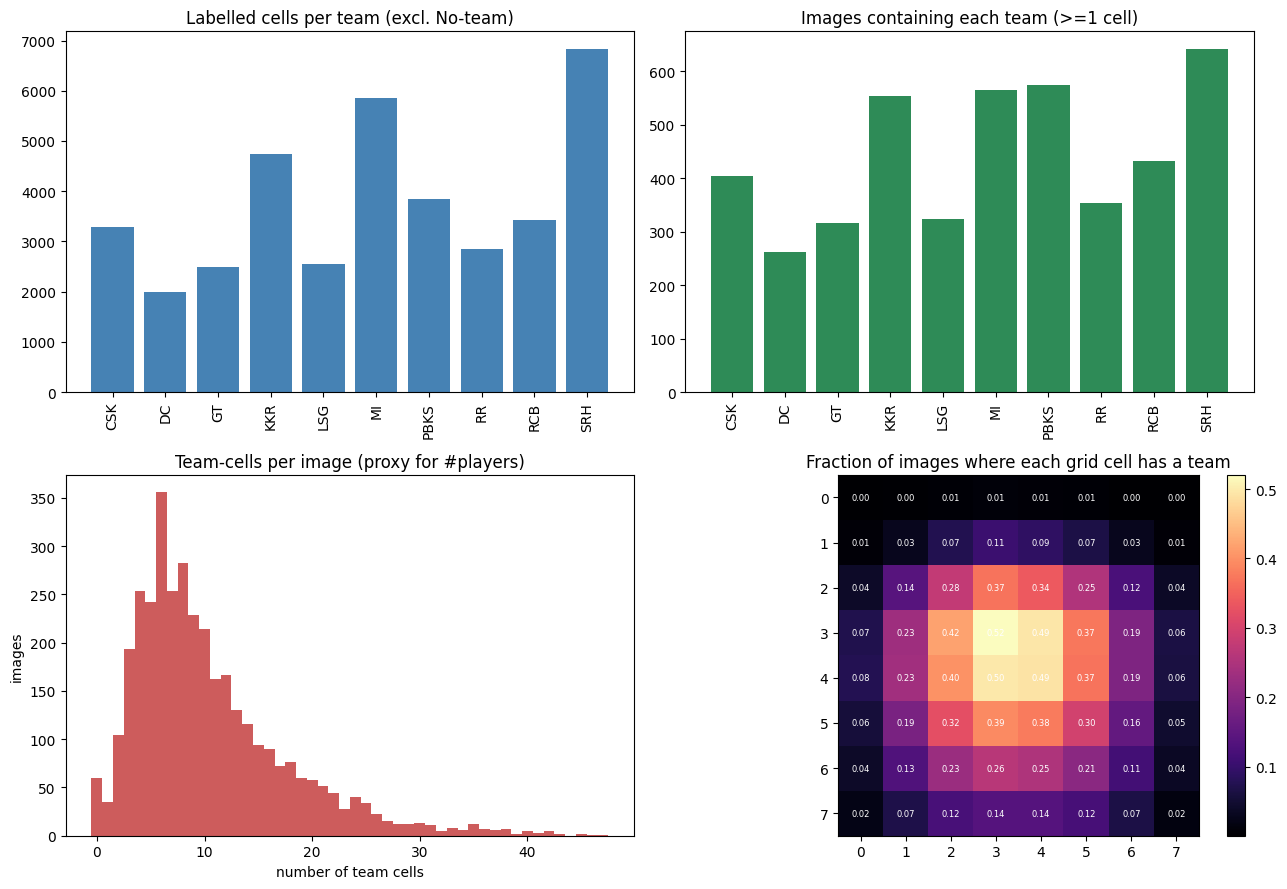


No-team cells: 192851 (83.6%) | team cells: 37869 (16.4%)
=> strong class imbalance; we use class-balanced classifiers and report macro-F1.


In [11]:
# ---- Per-label cell distribution ----
all_cells = master[CELL_COLS].to_numpy().ravel()
vals, cnts = np.unique(all_cells, return_counts=True)
dist = {int(v): int(c) for v, c in zip(vals, cnts)}
total_cells = all_cells.size
print("Cell-label distribution (label : #cells : % of all cells):")
for k in sorted(LABELS):
    c = dist.get(k, 0)
    print(f"  {k:2d} {LABELS[k]:7s}: {c:7d}  ({100*c/total_cells:5.2f}%)")

# images containing each team at least once
present = {k: 0 for k in LABELS}
for _, row in master.iterrows():
    for t in set(row[CELL_COLS].tolist()):
        present[int(t)] += 1

# ---- Plots: label frequency, images-per-team, players-per-image, grid heatmap ----
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (a) cell counts per team (excluding 0 to see the teams clearly)
team_ids = [k for k in sorted(LABELS) if k != 0]
axes[0,0].bar([LABELS[k] for k in team_ids], [dist.get(k,0) for k in team_ids],
              color="steelblue")
axes[0,0].set_title("Labelled cells per team (excl. No-team)")
axes[0,0].tick_params(axis="x", rotation=90)

# (b) images containing each team
axes[0,1].bar([LABELS[k] for k in team_ids], [present[k] for k in team_ids],
              color="seagreen")
axes[0,1].set_title("Images containing each team (>=1 cell)")
axes[0,1].tick_params(axis="x", rotation=90)

# (c) players (non-zero cells) per image
players_per_img = (master[CELL_COLS] > 0).sum(axis=1)
axes[1,0].hist(players_per_img, bins=range(0, int(players_per_img.max())+2),
               color="indianred", align="left")
axes[1,0].set_title("Team-cells per image (proxy for #players)")
axes[1,0].set_xlabel("number of team cells"); axes[1,0].set_ylabel("images")

# (d) spatial heatmap: how often each of the 64 grid cells is a team cell
occ = (master[CELL_COLS] > 0).to_numpy().mean(axis=0).reshape(GRID, GRID)
im = axes[1,1].imshow(occ, cmap="magma")
axes[1,1].set_title("Fraction of images where each grid cell has a team")
for r in range(GRID):
    for c in range(GRID):
        axes[1,1].text(c, r, f"{occ[r,c]:.2f}", ha="center", va="center",
                       color="white", fontsize=6)
plt.colorbar(im, ax=axes[1,1], fraction=0.046)
plt.tight_layout(); plt.show()

# ---- class imbalance summary ----
nonzero = total_cells - dist.get(0, 0)
print(f"\nNo-team cells: {dist.get(0,0)} ({100*dist.get(0,0)/total_cells:.1f}%) | "
      f"team cells: {nonzero} ({100*nonzero/total_cells:.1f}%)")
print("=> strong class imbalance; we use class-balanced classifiers and report macro-F1.")

## 2. Train/test split (in code, from `master.csv`)

We split at the **image level** (never letting cells of the same image fall in both sets). The split is **stratified** on each image's *dominant team* (the most frequent non-zero label in its 64 cells; images with no team form their own stratum) so every franchise tends to appear in both train and test. Falls back to a plain random split if a stratum is too small.

In [12]:
def dominant_team(row):
    """Most frequent non-zero cell label in an image; 0 if the image has no team."""
    vals = row[CELL_COLS].to_numpy()
    nz = vals[vals != 0]
    if nz.size == 0:
        return 0
    u, c = np.unique(nz, return_counts=True)
    return int(u[np.argmax(c)])

master["_strat"] = master.apply(dominant_team, axis=1)

# stratify only if every class has >=2 images; otherwise random split
strat = master["_strat"]
can_stratify = strat.value_counts().min() >= 2 and strat.nunique() > 1
train_df, test_df = train_test_split(
    master, test_size=TEST_SIZE, random_state=SPLIT_SEED,
    stratify=strat if can_stratify else None)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Split mode: {'stratified by dominant team' if can_stratify else 'random'}")
print(f"Train images: {len(train_df)} | Test images: {len(test_df)}")
print("Train dominant-team spread:", dict(train_df['_strat'].value_counts().sort_index()))
print("Test  dominant-team spread:", dict(test_df['_strat'].value_counts().sort_index()))

Split mode: stratified by dominant team
Train images: 2884 | Test images: 721
Train dominant-team spread: {0: np.int64(48), 1: np.int64(274), 2: np.int64(183), 3: np.int64(218), 4: np.int64(349), 5: np.int64(222), 6: np.int64(373), 7: np.int64(344), 8: np.int64(198), 9: np.int64(273), 10: np.int64(402)}
Test  dominant-team spread: {0: np.int64(12), 1: np.int64(68), 2: np.int64(46), 3: np.int64(55), 4: np.int64(87), 5: np.int64(56), 6: np.int64(93), 7: np.int64(86), 8: np.int64(50), 9: np.int64(68), 10: np.int64(100)}


## 3. Image loading

Enforces the 800×600 requirement: higher-resolution images are downscaled (allowed); images smaller than 800×600 are flagged and skipped (the brief forbids upscaling).

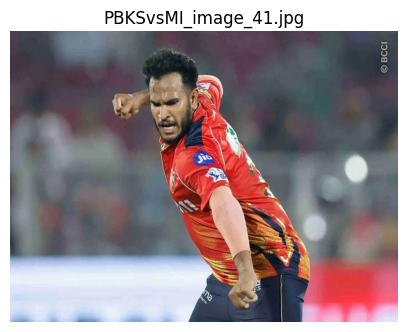

In [13]:
def load_image_bgr(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    h, w = img.shape[:2]
    if (w, h) != (IMG_W, IMG_H):
        if w < IMG_W or h < IMG_H:
            raise ValueError(f"{os.path.basename(path)}: {w}x{h} below 800x600 - skip (no upscaling).")
        img = cv2.resize(img, (IMG_W, IMG_H), interpolation=cv2.INTER_AREA)
    return img

def grid_cell_bounds(r, c):
    x0, y0 = c * CELL_W, r * CELL_H
    return x0, y0, x0 + CELL_W, y0 + CELL_H

# quick peek at one training image
_demo_path = train_df["_path"].iloc[0]
_demo = load_image_bgr(_demo_path)
plt.figure(figsize=(5,3.8))
plt.imshow(cv2.cvtColor(_demo, cv2.COLOR_BGR2RGB))
plt.title(os.path.basename(_demo_path)); plt.axis("off"); plt.show()

## 4. Lighting-variation augmentation — floodlight V-drop & overexposure

IPL matches vary in floodlight intensity and broadcast exposure. We augment **training** cells via the HSV **V** (brightness) channel:
- **Floodlight V-drop** — multiply V by `<1` (weaker floodlights / shadow / dusk).
- **Overexposure** — raise V with gain `>1`, soft highlight roll-off + mild desaturation (blown-out broadcast).

Our colour features deliberately downweight brightness, so these teach the classifier to lean on hue/chroma & texture, not absolute brightness.

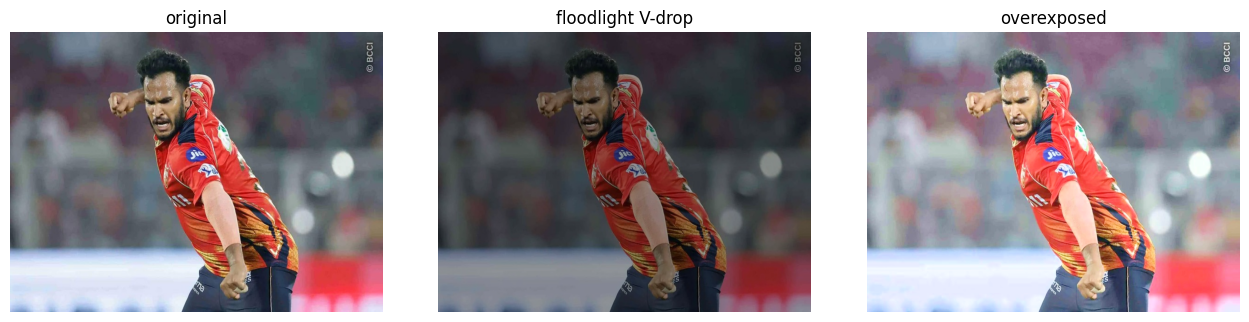

In [14]:
def aug_floodlight_vdrop(bgr, factor=None, rng=None):
    rng = rng or np.random.default_rng()
    factor = factor if factor is not None else float(rng.uniform(0.55, 0.78))
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    hsv[..., 2] = np.clip(hsv[..., 2] * factor, 0, 255)
    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

def aug_overexposure(bgr, gain=None, rng=None):
    rng = rng or np.random.default_rng()
    gain = gain if gain is not None else float(rng.uniform(1.25, 1.6))
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    v = hsv[..., 2] * gain
    v = 255.0 * (1.0 - np.exp(-v / 200.0)) + 0.15 * v          # soft roll-off
    hsv[..., 2] = np.clip(v, 0, 255)
    hsv[..., 1] *= float(rng.uniform(0.8, 0.95))               # mild desaturation
    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

def build_cell_augmenters():
    fns = [("orig", lambda x, rng: x)]
    if AUG_FLOODLIGHT_VDROP: fns.append(("vdrop",  lambda x, rng: aug_floodlight_vdrop(x, rng=rng)))
    if AUG_OVEREXPOSURE:     fns.append(("overexp",lambda x, rng: aug_overexposure(x, rng=rng)))
    return fns

# visual sanity check
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
for a,(t,im) in zip(ax,[("original",_demo),
                        ("floodlight V-drop",aug_floodlight_vdrop(_demo,0.6)),
                        ("overexposed",aug_overexposure(_demo,1.5))]):
    a.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

## 5. Hand-crafted feature extractors

Each operates on one **grid cell** (100×75 BGR patch) and returns a fixed-length vector. The cell feature vector is the concatenation of all enabled blocks. No learned/CNN features anywhere.

In [15]:
def feat_lbp(gray):
    """Uniform LBP histogram - texture, brightness-invariant."""
    lbp = local_binary_pattern(gray, LBP_P, LBP_R, method="uniform")
    n_bins = LBP_P + 2
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins))
    hist = hist.astype(np.float32)
    return hist / (hist.sum() + 1e-7)

def feat_hog(gray):
    """HOG - coarse shape/edge structure."""
    g = cv2.resize(gray, (64, 64), interpolation=cv2.INTER_AREA)
    return hog(g, orientations=9, pixels_per_cell=(16, 16),
               cells_per_block=(2, 2), block_norm="L2-Hys",
               feature_vector=True).astype(np.float32)

def feat_hs(bgr, h_bins=12, s_bins=8):
    """2D Hue-Saturation histogram - colour identity, ignores V."""
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0, 1], None, [h_bins, s_bins], [0,180,0,256])
    cv2.normalize(hist, hist, 0, 1, cv2.NORM_MINMAX)
    return hist.flatten().astype(np.float32)

def feat_lab(bgr, bins=8):
    """LAB per-channel histograms + colour moments (mean, std, skew)."""
    lab = rgb2lab(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    ranges = [(0,100),(-128,127),(-128,127)]
    feats = []
    for ch in range(3):
        x = lab[..., ch].ravel()
        h,_ = np.histogram(x, bins=bins, range=ranges[ch])
        h = h.astype(np.float32); h /= (h.sum()+1e-7)
        mean = x.mean(); std = x.std()+1e-7
        skew = np.mean(((x-mean)/std)**3)
        feats.append(np.concatenate([h, [mean/128.0, std/128.0, skew]]))
    return np.concatenate(feats).astype(np.float32)

def cell_features(bgr_cell):
    gray = cv2.cvtColor(bgr_cell, cv2.COLOR_BGR2GRAY)
    parts = []
    if USE_LBP:    parts.append(feat_lbp(gray))
    if USE_HOG:    parts.append(feat_hog(gray))
    if USE_HS:     parts.append(feat_hs(bgr_cell))
    if USE_LAB:    parts.append(feat_lab(bgr_cell))
    return np.concatenate(parts).astype(np.float32)

_dim = cell_features(_demo[0:CELL_H, 0:CELL_W]).shape[0]
print(f"Per-cell feature vector length: {_dim}")

Per-cell feature vector length: 463


## 6. Build feature matrices from the split

Every grid cell of every image is one sample. Lighting augmentation is applied to **training** images only; test images are featurised as-is. Labels come straight from the `c01..c64` columns of `master.csv`.

In [ ]:
def image_to_cell_features(bgr):
    """(64, D) feature matrix for one image, row-major over cells."""
    feats = []
    for r in range(GRID):
        for c in range(GRID):
            x0,y0,x1,y1 = grid_cell_bounds(r,c)
            feats.append(cell_features(bgr[y0:y1, x0:x1]))
    return np.stack(feats, axis=0)

def feature_names():
    """Human-readable name for every dimension, in the SAME order as cell_features()."""
    names = []
    if USE_LBP:
        names += [f"lbp_{i}" for i in range(LBP_P + 2)]
    if USE_HOG:
        hog_len = feat_hog(np.zeros((CELL_H, CELL_W), np.uint8)).shape[0]
        names += [f"hog_{i}" for i in range(hog_len)]
    if USE_HS:
        names += [f"hs_h{h}_s{s}" for h in range(12) for s in range(8)]
    if USE_LAB:
        for ch in ("L", "A", "B"):
            names += [f"lab_{ch}_bin{i}" for i in range(8)]
            names += [f"lab_{ch}_mean", f"lab_{ch}_std", f"lab_{ch}_skew"]
    return names

FEATURE_NAMES = feature_names()
META_COLS_OUT = ["image", "split", "aug", "cell_index", "grid_row", "grid_col"]

def build_matrix(df, split_tag, augment=False):
    """Compute (X, y, meta) for a split. Prints progress every 50 images."""
    X, y, meta = [], [], []
    augmenters = build_cell_augmenters() if augment else [("orig", lambda x,rng:x)]
    rng = np.random.default_rng(RNG)
    skipped = 0
    n = len(df)
    import time; t0 = time.time()
    for i, (_, row) in enumerate(df.iterrows(), 1):
        try:
            bgr = load_image_bgr(row["_path"])
        except ValueError:
            skipped += 1; continue
        labels = row[CELL_COLS].to_numpy(dtype=np.int64)
        img_name = os.path.basename(row["_path"])
        for aug_name, aug_fn in augmenters:
            feats = image_to_cell_features(aug_fn(bgr, rng))
            X.append(feats); y.append(labels)
            for idx in range(N_CELLS):
                meta.append({"image": img_name, "split": split_tag, "aug": aug_name,
                             "cell_index": idx + 1, "grid_row": idx // GRID,
                             "grid_col": idx % GRID})
        if i % 50 == 0 or i == n:
            el = time.time() - t0
            eta = el / i * (n - i)
            print(f"   [{split_tag}] {i}/{n} images  |  {el:6.1f}s elapsed  |  ~{eta:6.1f}s left",
                  flush=True)
    if skipped:
        print(f"  (skipped {skipped} under-sized images)")
    return np.concatenate(X, axis=0), np.concatenate(y, axis=0), meta

def save_features_csv(out_csv=FEATURES_CSV):
    parts = []
    for X, y, meta in [(X_train, y_train, meta_train), (X_test, y_test, meta_test)]:
        m = pd.DataFrame(meta, columns=META_COLS_OUT)
        m["label"] = y.astype(int)
        f = pd.DataFrame(X, columns=FEATURE_NAMES)
        parts.append(pd.concat([m.reset_index(drop=True), f.reset_index(drop=True)], axis=1))
    out = pd.concat(parts, axis=0, ignore_index=True)
    out.to_csv(out_csv, index=False)
    print(f"Cached features -> {out_csv}  shape={out.shape}")
    return out

def load_features_csv(in_csv=FEATURES_CSV):
    df = pd.read_csv(in_csv)
    feat_cols = [c for c in df.columns if c not in (META_COLS_OUT + ["label"])]
    def split_part(tag):
        d = df[df["split"] == tag]
        X = d[feat_cols].to_numpy(dtype=np.float32)
        y = d["label"].to_numpy(dtype=np.int64)
        meta = d[META_COLS_OUT].to_dict("records")
        return X, y, meta
    Xtr, ytr, mtr = split_part("Train")
    Xte, yte, mte = split_part("Test")
    print(f"Loaded cached features from {in_csv}  (train {Xtr.shape}, test {Xte.shape})")
    return (Xtr, ytr, mtr), (Xte, yte, mte), feat_cols

# ---- Load cached features if available, else compute and cache ----
if (not FORCE_RECOMPUTE) and os.path.exists(FEATURES_CSV):
    (X_train, y_train, meta_train), (X_test, y_test, meta_test), cached_cols = load_features_csv()
    if cached_cols != FEATURE_NAMES:
        print("WARNING: cached feature columns differ from current feature config.")
        print("         Set FORCE_RECOMPUTE = True in CONFIG to rebuild from images.")
else:
    print("Featurising TRAIN (with lighting augmentation) ...")
    X_train, y_train, meta_train = build_matrix(train_df, "Train", augment=True)
    print("Featurising TEST ...")
    X_test,  y_test,  meta_test  = build_matrix(test_df, "Test", augment=False)
    save_features_csv()

assert X_train.shape[1] == len(FEATURE_NAMES), "feature dim mismatch vs FEATURE_NAMES"
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("train class counts:", dict(zip(*[a.tolist() for a in np.unique(y_train, return_counts=True)])))


Featurising TRAIN (with lighting augmentation) ...
   [Train] 50/2884 images  |    59.6s elapsed  |  ~3380.7s left
   [Train] 100/2884 images  |   120.8s elapsed  |  ~3363.9s left
   [Train] 150/2884 images  |   182.5s elapsed  |  ~3326.4s left
   [Train] 200/2884 images  |   246.3s elapsed  |  ~3305.9s left
   [Train] 250/2884 images  |   326.9s elapsed  |  ~3444.1s left
   [Train] 300/2884 images  |   435.7s elapsed  |  ~3752.6s left
   [Train] 350/2884 images  |   531.9s elapsed  |  ~3850.9s left
   [Train] 400/2884 images  |   615.6s elapsed  |  ~3822.9s left
   [Train] 450/2884 images  |   696.8s elapsed  |  ~3768.7s left
   [Train] 500/2884 images  |   783.5s elapsed  |  ~3736.0s left
   [Train] 550/2884 images  |   853.0s elapsed  |  ~3619.9s left
   [Train] 600/2884 images  |   917.7s elapsed  |  ~3493.2s left
   [Train] 650/2884 images  |  2804.5s elapsed  |  ~9638.9s left
   [Train] 700/2884 images  |  2877.8s elapsed  |  ~8978.8s left
   [Train] 750/2884 images  |  2959.5s e

## 6b. Feature cache (`features.csv`)

The build step above **caches** all computed features to `features.csv`. On any later run it **reloads** from that file instead of recomputing — featurising ~4,000 images takes a couple of hours, but reloading the cache takes seconds.

- To force a fresh recompute (e.g. after changing feature toggles), set `FORCE_RECOMPUTE = True` in the CONFIG cell.
- The cell below just previews the cached table.

In [19]:
# Features were cached to features.csv during the build step above
# (or loaded from it on a repeat run). Preview the cached table:
import pandas as _pd
features_df = _pd.read_csv(FEATURES_CSV, nrows=5)
print("features.csv columns:", len(features_df.columns),
      "| first feature col:", FEATURE_NAMES[0], "| last:", FEATURE_NAMES[-1])
features_df.head()


features.csv columns: 470 | first feature col: lbp_0 | last: lab_B_skew


,image,split,aug,cell_index,grid_row,grid_col,label,lbp_0,lbp_1,lbp_2,...,lab_B_bin1,lab_B_bin2,lab_B_bin3,lab_B_bin4,lab_B_bin5,lab_B_bin6,lab_B_bin7,lab_B_mean,lab_B_std,lab_B_skew
0,PBKSvsMI_image_41.jpg,Train,orig,1,0,0,0,0.004133,0.028800,0.006400,...,0.0,0.0,1.0000,0.0000,0.0,0.0,0.0,-0.050727,0.013131,-1.310121
1,PBKSvsMI_image_41.jpg,Train,orig,2,0,1,0,0.005600,0.026400,0.008133,...,0.0,0.0,1.0000,0.0000,0.0,0.0,0.0,-0.077743,0.015840,1.125042
2,PBKSvsMI_image_41.jpg,Train,orig,3,0,2,0,0.011733,0.040267,0.017200,...,0.0,0.0,0.9368,0.0632,0.0,0.0,0.0,-0.038651,0.014178,2.080826
3,PBKSvsMI_image_41.jpg,Train,orig,4,0,3,0,0.024267,0.052800,0.038000,...,0.0,0.0,0.9028,0.0972,0.0,0.0,0.0,-0.034512,0.020811,0.491593
4,PBKSvsMI_image_41.jpg,Train,orig,5,0,4,0,0.007467,0.032267,0.008533,...,0.0,0.0,1.0000,0.0000,0.0,0.0,0.0,-0.056504,0.012480,1.357693


## 7. Model selection & training

Three non-CNN classifiers are compared by stratified cross-validation (macro-F1); the best is refit on all training cells:

- **Random Forest** — bagged decision trees, robust to mixed feature scales, handles class imbalance via balanced subsampling.
- **XGBoost** — gradient-boosted trees, strong tabular performance (`multi:softprob`, histogram tree method).
- **SVM (RBF)** — kernel margin classifier on standardised features, effective on high-dim colour/texture histograms.

The scaler (where needed) + classifier are stored together as one `Pipeline`, so inference is a single call.

In [24]:
# Three non-CNN classifiers: Random Forest, XGBoost, and a (fast) linear SVM.
# Labels are 0..10 (contiguous) - exactly what XGBoost expects for multiclass.
n_classes_train = int(np.max(y_train)) + 1

# -------------------------------------------------------------------
# SPEED CONTROL
#   With ~hundreds of thousands of cell-samples, an RBF-kernel SVM and
#   3-fold cross-validation are extremely slow (hours). By default we:
#     * compare models on a SINGLE fast holdout split (no k-fold CV), and
#     * use LinearSVC instead of SVC(kernel="rbf").
#   Set USE_CV = True only if you have time and want k-fold scores.
#   Set USE_RBF_SVM = True only on a SMALL dataset (it does not scale).
# -------------------------------------------------------------------
USE_CV       = False    # False = single holdout (fast); True = 3-fold CV (slow)
USE_RBF_SVM  = False    # False = LinearSVC (fast, scales); True = RBF SVC (small data only)
CV_FOLDS     = 3
VAL_FRACTION = 0.2      # holdout size used when USE_CV is False

svm_step = (("clf", SVC(kernel="rbf", C=8.0, gamma="scale",
                        class_weight="balanced", random_state=RNG))
            if USE_RBF_SVM else
            ("clf", LinearSVC(C=1.0, class_weight="balanced",
                              dual=False, max_iter=5000, random_state=RNG)))

candidates = {
    "random_forest": Pipeline([
        ("clf", RandomForestClassifier(
            n_estimators=300, max_depth=None, min_samples_leaf=2,
            class_weight="balanced_subsample", n_jobs=-1, random_state=RNG)),
    ]),
    "xgboost": Pipeline([
        ("clf", XGBClassifier(
            objective="multi:softprob", num_class=n_classes_train,
            n_estimators=300, learning_rate=0.15, max_depth=6,
            subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
            tree_method="hist", eval_metric="mlogloss",
            n_jobs=-1, random_state=RNG)),
    ]),
    "svm": Pipeline([("scaler", StandardScaler()), svm_step]),
}

import time
scores = {}
if USE_CV:
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RNG)
    for name, pipe in candidates.items():
        t0 = time.time()
        s = cross_val_score(pipe, X_train, y_train, cv=cv,
                            scoring="f1_macro", n_jobs=-1)
        scores[name] = s.mean()
        print(f"{name:13s}  CV macro-F1 = {s.mean():.4f} +/- {s.std():.4f}  "
              f"({time.time()-t0:.0f}s)")
else:
    # single stratified holdout: fit on a sub-train, score on a small validation set
    try:
        Xtr, Xval, ytr, yval = train_test_split(
            X_train, y_train, test_size=VAL_FRACTION,
            random_state=RNG, stratify=y_train)
    except ValueError:
        Xtr, Xval, ytr, yval = train_test_split(
            X_train, y_train, test_size=VAL_FRACTION, random_state=RNG)
    for name, pipe in candidates.items():
        t0 = time.time()
        pipe.fit(Xtr, ytr)
        vpred = pipe.predict(Xval)
        scores[name] = f1_score(yval, vpred, average="macro")
        print(f"{name:13s}  holdout macro-F1 = {scores[name]:.4f}  "
              f"({time.time()-t0:.0f}s)")

best_name = max(scores, key=scores.get)
print("\nBest model:", best_name)

# refit the winner on the FULL training set
import time as _t; _t0 = _t.time()
model = candidates[best_name]
model.fit(X_train, y_train)
print(f"Refit best model on full training set complete. ({_t.time()-_t0:.0f}s)")


random_forest  holdout macro-F1 = 0.6652  (2493s)
xgboost        holdout macro-F1 = 0.7837  (2536s)
svm            holdout macro-F1 = 0.5126  (1251s)

Best model: xgboost
Refit best model on full training set complete. (2995s)


## 8. Evaluation on train & test

== TRAIN ==  accuracy=0.9886  macro-F1=0.9732
              precision    recall  f1-score   support

    0:NoTeam       0.99      1.00      0.99    462780
       1:CSK       1.00      0.99      0.99      7941
        2:DC       0.99      0.98      0.99      4842
        3:GT       0.99      0.99      0.99      6033
       4:KKR       0.98      0.98      0.98     11196
       5:LSG       0.99      1.00      1.00      6240
        6:MI       0.94      0.93      0.94     14232
      7:PBKS       0.97      0.91      0.94      9138
        8:RR       1.00      0.99      1.00      6918
       9:RCB       0.98      0.93      0.96      8127
      10:SRH       0.97      0.90      0.93     16281

    accuracy                           0.99    553728
   macro avg       0.98      0.96      0.97    553728
weighted avg       0.99      0.99      0.99    553728

== TEST ==  accuracy=0.9003  macro-F1=0.6248
              precision    recall  f1-score   support

    0:NoTeam       0.92      0.98      0.

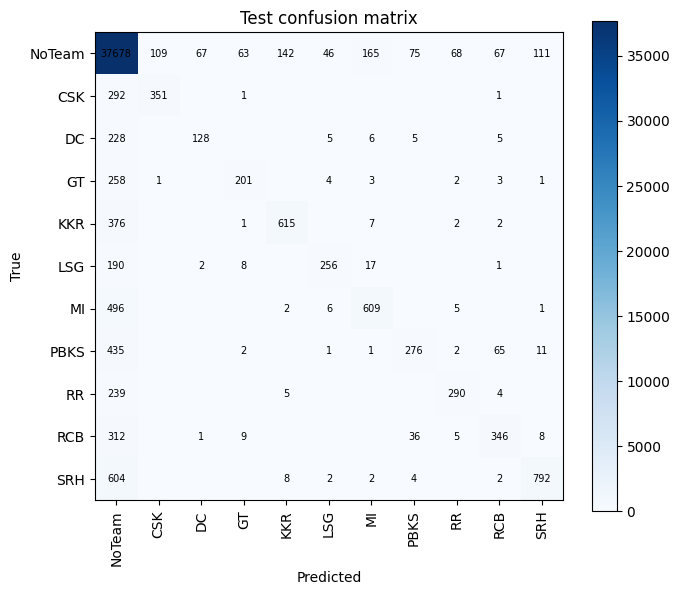

In [26]:
def evaluate(tag, X, y):
    pred = model.predict(X)
    acc = accuracy_score(y, pred); f1m = f1_score(y, pred, average="macro")
    print(f"== {tag} ==  accuracy={acc:.4f}  macro-F1={f1m:.4f}")
    present = sorted(set(y.tolist()) | set(pred.tolist()))
    names = [f"{k}:{LABELS[k]}" for k in present]
    print(classification_report(y, pred, labels=present, target_names=names, zero_division=0))
    return pred

pred_train = evaluate("TRAIN", X_train, y_train)
pred_test  = evaluate("TEST",  X_test,  y_test)

labels_present = sorted(set(y_test.tolist()) | set(pred_test.tolist()))
cm = confusion_matrix(y_test, pred_test, labels=labels_present)
fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels_present))); ax.set_yticks(range(len(labels_present)))
ax.set_xticklabels([LABELS[k] for k in labels_present], rotation=90)
ax.set_yticklabels([LABELS[k] for k in labels_present])
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Test confusion matrix")
for i in range(len(labels_present)):
    for j in range(len(labels_present)):
        if cm[i,j]: ax.text(j,i,cm[i,j],ha="center",va="center",fontsize=7)
plt.colorbar(im); plt.tight_layout(); plt.show()

## 9. Save model weights — `model_<teamname>.pkl`

In [27]:
model_path = f"model_{TEAM_NAME}.pkl"
joblib.dump({
    "model": model, "best_name": best_name, "labels": LABELS,
    "config": {"IMG_W":IMG_W,"IMG_H":IMG_H,"GRID":GRID,"CELL_W":CELL_W,"CELL_H":CELL_H,
               "features":{"LBP":USE_LBP,"HOG":USE_HOG,"HS":USE_HS,"LAB":USE_LAB},
               "LBP_P":LBP_P,"LBP_R":LBP_R},
}, model_path)
print("Saved:", model_path)

Saved: model_teamname.pkl


## 10. Inference / pipeline code

Reads the saved pickle, accepts a single **test instance** (image path), and returns the 64 per-cell predictions — the "Pipeline Code" deliverable.

In [28]:
def load_pipeline(path):
    return joblib.load(path)

def predict_image(bundle, image_path):
    """Length-64 list of integer cell labels (row-major c01..c64)."""
    bgr = load_image_bgr(image_path)
    return bundle["model"].predict(image_to_cell_features(bgr)).astype(int).tolist()

_bundle = load_pipeline(model_path)
_sample = test_df["_path"].iloc[0]
_pred = predict_image(_bundle, _sample)
print("Predictions for", os.path.basename(_sample), ":")
print(np.array(_pred).reshape(GRID, GRID))

Predictions for SRHvsMI_image_247.jpg :
[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 8 8 0 0 0 0]
 [0 0 0 0 0 0 0 0]]


Image: SRHvsMI_image_247.jpg
  1) Player-regions detected (cells): 2 cells
  2) Estimated player count (blobs):  1
  3) Team assignment: {'RR': 1}


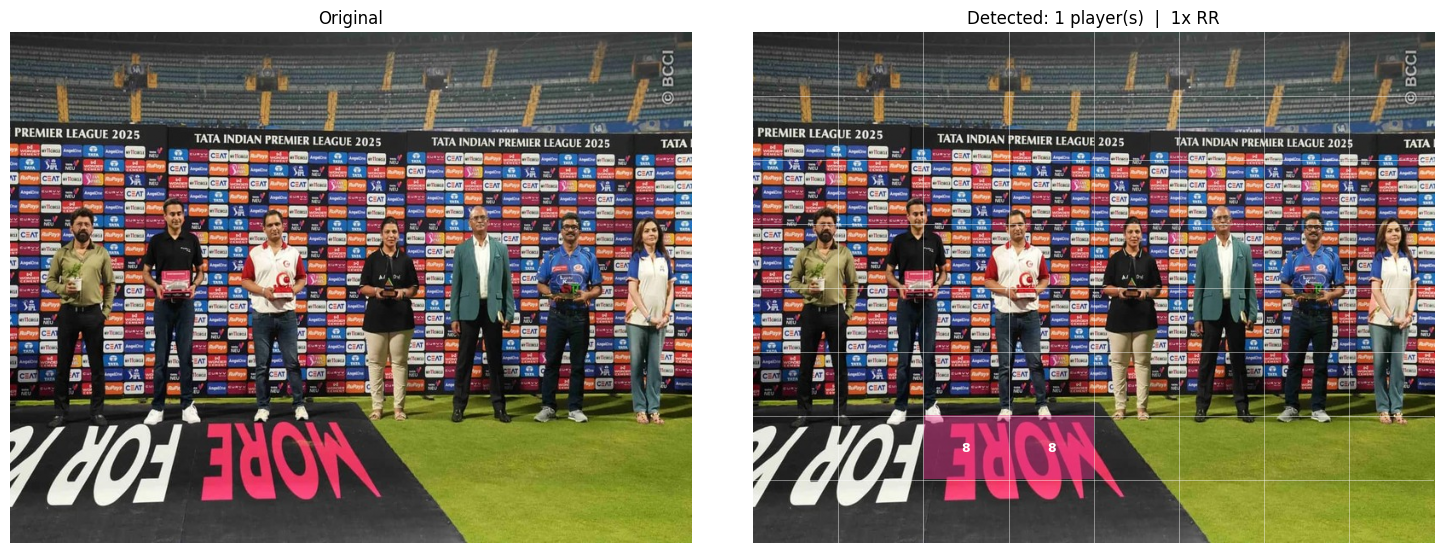

------------------------------------------------------------
Image: MIvsRCB_image_11.jpg
  1) Player-regions detected (cells): 6 cells
  2) Estimated player count (blobs):  1
  3) Team assignment: {'RCB': 1}


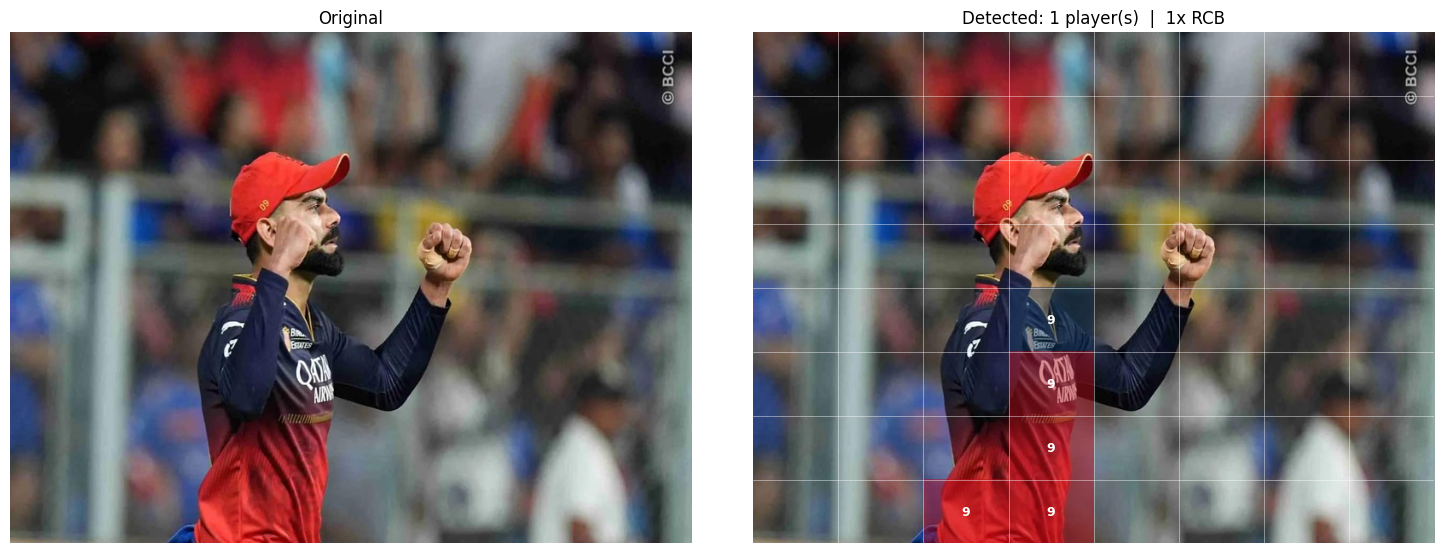

------------------------------------------------------------
Image: SRHvsMI_image_259.jpg
  1) Player-regions detected (cells): 24 cells
  2) Estimated player count (blobs):  1
  3) Team assignment: {'MI': 1}


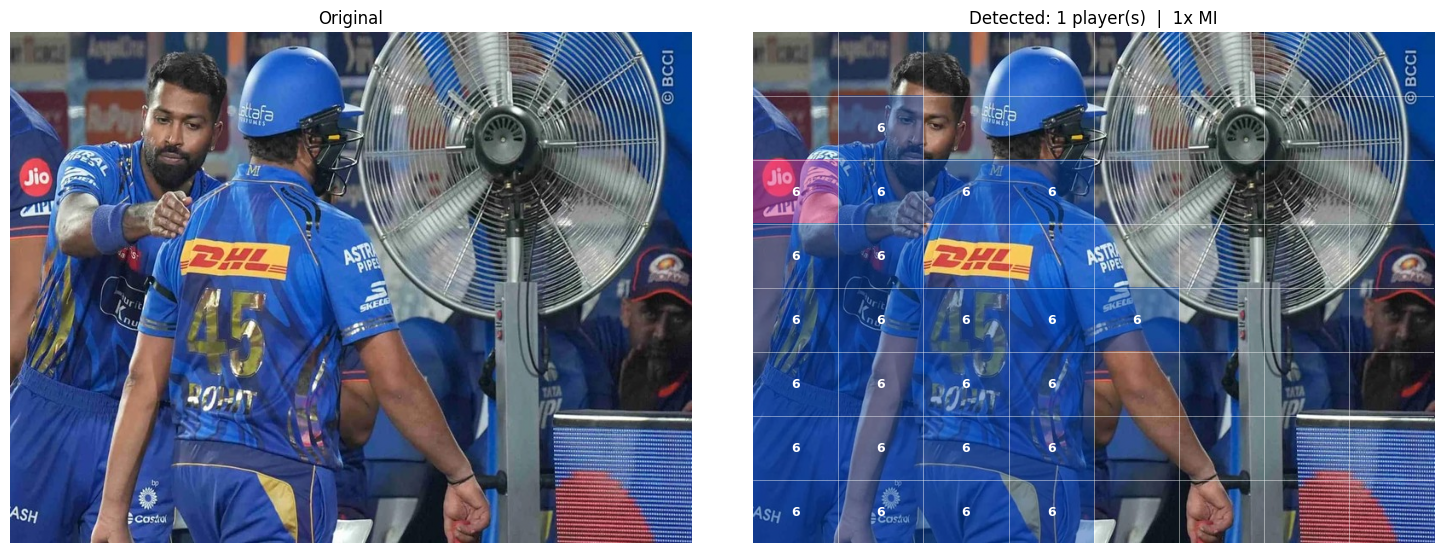

------------------------------------------------------------


In [37]:
from scipy import ndimage

# Approximate broadcast/display colours per team for the overlay (RGB 0-1)
TEAM_RGB = {
    1:(0.96,0.86,0.10), 2:(0.10,0.30,0.75), 3:(0.05,0.20,0.35), 4:(0.45,0.20,0.60),
    5:(0.00,0.55,0.85), 6:(0.00,0.25,0.65), 7:(0.80,0.05,0.10), 8:(0.90,0.20,0.55),
    9:(0.75,0.05,0.10), 10:(0.95,0.45,0.05),
}

# -------------------------------------------------------------------
# COUNTING PARAMETERS (tune these for your data)
#   The model labels each grid cell by team colour; it has no concept of a
#   "human", so raw cell groups over-count (crowd colour leaks in, and one
#   player's body can get split across two team labels). These rules make the
#   grid-based count behave more like a person count:
#     1. MERGE_ACROSS_TEAMS: group ALL adjacent occupied cells into one blob
#        (regardless of team), so helmet+jersey+pads of one player = 1 person.
#        Each blob is then assigned its MAJORITY team label.
#     2. MIN_BLOB_CELLS: discard blobs smaller than this (isolated 1-cell specks
#        are usually crowd / advertising / noise, not a player).
#     3. CROWD_TOP_ROWS: ignore the top N grid rows (crowd stands live up there).
# -------------------------------------------------------------------
MERGE_ACROSS_TEAMS = True   # merge neighbouring cells even if teams differ
MIN_BLOB_CELLS     = 2      # a real player usually spans >=2 cells; 1 = keep all
CROWD_TOP_ROWS     = 0      # set e.g. 2 to ignore the top 2 rows (crowd zone)

def grid_from_preds(preds):
    """64-list -> 8x8 int array."""
    return np.asarray(preds, dtype=int).reshape(GRID, GRID)

def _blob_team(grid, ys, xs):
    """Majority non-zero team label among a blob's cells."""
    vals = grid[ys, xs]
    vals = vals[vals > 0]
    if vals.size == 0:
        return 0
    u, c = np.unique(vals, return_counts=True)
    return int(u[np.argmax(c)])

def detect_count_assign(preds,
                        merge_across_teams=None, min_blob_cells=None,
                        crowd_top_rows=None):
    """Estimate players from the 64-cell grid using the smarter rules above.
    Returns detection, per-team counts, total count, and the kept blobs."""
    merge_across_teams = MERGE_ACROSS_TEAMS if merge_across_teams is None else merge_across_teams
    min_blob_cells     = MIN_BLOB_CELLS     if min_blob_cells     is None else min_blob_cells
    crowd_top_rows     = CROWD_TOP_ROWS     if crowd_top_rows     is None else crowd_top_rows

    grid = grid_from_preds(preds).copy()
    if crowd_top_rows > 0:
        grid[:crowd_top_rows, :] = 0          # suppress crowd zone

    structure = np.ones((3, 3), dtype=int)    # 8-connectivity
    blobs = []

    if merge_across_teams:
        # one mask over ALL occupied cells; each connected region = one player
        mask = (grid > 0)
        labeled, n = ndimage.label(mask, structure=structure)
        for b in range(1, n + 1):
            ys, xs = np.where(labeled == b)
            if len(ys) < min_blob_cells:
                continue                      # drop tiny specks (crowd/noise)
            team = _blob_team(grid, ys, xs)
            blobs.append({"team": team, "team_name": LABELS[team],
                          "cells": [int(r*GRID + c + 1) for r, c in zip(ys, xs)],
                          "n_cells": int(len(ys))})
    else:
        # group per team separately (original behaviour)
        for team in range(1, 11):
            m = (grid == team)
            if not m.any():
                continue
            labeled, n = ndimage.label(m, structure=structure)
            for b in range(1, n + 1):
                ys, xs = np.where(labeled == b)
                if len(ys) < min_blob_cells:
                    continue
                blobs.append({"team": team, "team_name": LABELS[team],
                              "cells": [int(r*GRID + c + 1) for r, c in zip(ys, xs)],
                              "n_cells": int(len(ys))})

    per_team = {}
    for bl in blobs:
        per_team[bl["team"]] = per_team.get(bl["team"], 0) + 1
    total_players = len(blobs)
    occupied_cells = int((grid > 0).sum())
    return {"grid": grid, "total_players": total_players,
            "players_per_team": {LABELS[k]: v for k, v in sorted(per_team.items())},
            "occupied_cells": occupied_cells, "blobs": blobs}

def summarize_image(image_path, show=True):
    """Run the model on one image and report the three outcomes (+ optional overlay)."""
    preds = predict_image(_bundle, image_path)
    res = detect_count_assign(preds)

    print(f"Image: {os.path.basename(image_path)}")
    print(f"  1) Player-regions detected (cells): {res['occupied_cells']} cells")
    print(f"  2) Estimated player count (blobs):  {res['total_players']}")
    print(f"  3) Team assignment: {res['players_per_team'] or 'no teams detected'}")

    if show:
        bgr = load_image_bgr(image_path)
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).astype(float) / 255.0
        overlay = rgb.copy()
        grid = res["grid"]
        # tint only the cells of KEPT blobs (so dropped specks don't show)
        kept_cells = {c for bl in res["blobs"] for c in bl["cells"]}
        for r in range(GRID):
            for c in range(GRID):
                cell_id = r*GRID + c + 1
                if cell_id not in kept_cells:
                    continue
                t = grid[r, c]
                x0, y0, x1, y1 = grid_cell_bounds(r, c)
                overlay[y0:y1, x0:x1] = 0.55*overlay[y0:y1, x0:x1] + 0.45*np.array(TEAM_RGB[t])

        fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
        ax[0].imshow(rgb); ax[0].set_title("Original"); ax[0].axis("off")
        ax[1].imshow(overlay)
        ax[1].set_title(f"Detected: {res['total_players']} player(s)  |  "
                        + ", ".join(f"{v}x {k}" for k, v in res["players_per_team"].items()))
        for k in range(1, GRID):
            ax[1].axhline(k*CELL_H, color="white", lw=0.5, alpha=0.6)
            ax[1].axvline(k*CELL_W, color="white", lw=0.5, alpha=0.6)
        # outline each kept blob and label it with its team number
        for bl in res["blobs"]:
            for cid in bl["cells"]:
                r, c = (cid-1)//GRID, (cid-1)%GRID
                ax[1].text(c*CELL_W + CELL_W/2, r*CELL_H + CELL_H/2, str(bl["team"]),
                           ha="center", va="center", color="white", fontsize=9, fontweight="bold")
        ax[1].axis("off")
        plt.tight_layout(); plt.show()
    return res

# Demo on a few test images
for _p in test_df["_path"].head(3):
    summarize_image(_p, show=True)
    print("-" * 60)


In [36]:
def build_summary_csv(out_csv="image_summary.csv"):
    rows = []
    for df, tag in [(train_df, "Train"), (test_df, "Test")]:
        for _, r in df.iterrows():
            try:
                res = detect_count_assign(predict_image(_bundle, r["_path"]))
            except ValueError:
                continue
            row = {"image": os.path.basename(r["_path"]), "split": tag,
                   "estimated_players": res["total_players"],
                   "occupied_cells": res["occupied_cells"]}
            for k in range(1, 11):
                row[f"n_{LABELS[k]}"] = res["players_per_team"].get(LABELS[k], 0)
            rows.append(row)
    out = pd.DataFrame(rows)
    out.to_csv(out_csv, index=False)
    print("Wrote", out_csv, "shape", out.shape)
    return out

summary_df = build_summary_csv("image_summary.csv")
summary_df.head()

Wrote image_summary.csv shape (3605, 14)


,image,split,estimated_players,occupied_cells,n_CSK,n_DC,n_GT,n_KKR,n_LSG,n_MI,n_PBKS,n_RR,n_RCB,n_SRH
0,PBKSvsMI_image_41.jpg,Train,1,11,0,0,0,0,0,0,1,0,0,0
1,SRHvsMI_image_28.jpg,Train,1,37,0,0,0,0,0,1,0,0,0,0
2,KKRvsSRH_image_21.jpg,Train,1,10,0,0,0,1,0,0,0,0,0,0
3,RCBvsPBKS_image_75.jpg,Train,1,9,0,0,0,0,0,0,1,0,0,0
4,KKRvsSRH_image_5.jpg,Train,2,30,0,0,0,2,0,0,0,0,0,0


## 11. Predictions CSV — required output format

One row per image: `Image File Name, Train Or Test, c01 … c64`, values `0–10`. The final model is run on the original (un-augmented) train and test images, one row each, tagged with which split they came from.

In [35]:
def cells_to_row(image_name, split_tag, preds):
    row = {"Image File Name": image_name, "Train Or Test": split_tag}
    for i in range(N_CELLS):
        row[f"c{i+1:02d}"] = int(preds[i])
    return row

def build_predictions_csv(out_csv="predictions.csv"):
    rows = []
    for df, tag in [(train_df, "Train"), (test_df, "Test")]:
        for _, r in df.iterrows():
            try:
                preds = predict_image(_bundle, r["_path"])
            except ValueError:
                continue   # skipped under-sized image
            rows.append(cells_to_row(os.path.basename(r["_path"]), tag, preds))
    cols = ["Image File Name","Train Or Test"] + [f"c{i+1:02d}" for i in range(N_CELLS)]
    out = pd.DataFrame(rows)[cols]
    out.to_csv(out_csv, index=False)
    print("Wrote", out_csv, "shape", out.shape)
    return out

pred_df = build_predictions_csv("predictions.csv")
pred_df.head()

Wrote predictions.csv shape (3605, 66)


,Image File Name,Train Or Test,c01,c02,c03,c04,c05,c06,c07,c08,...,c55,c56,c57,c58,c59,c60,c61,c62,c63,c64
0,PBKSvsMI_image_41.jpg,Train,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,7,7,0,0
1,SRHvsMI_image_28.jpg,Train,0,0,0,0,0,0,0,0,...,6,0,0,0,6,6,6,6,6,0
2,KKRvsSRH_image_21.jpg,Train,0,0,0,0,0,0,0,0,...,0,0,0,0,0,4,0,0,0,0
3,RCBvsPBKS_image_75.jpg,Train,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,KKRvsSRH_image_5.jpg,Train,0,0,0,0,0,0,0,0,...,4,4,4,4,4,0,0,4,4,4


## 12. Notes

- The notebook reads labels **only** from `data/master.csv` (columns `image, labelled_by, num_players, submitted_by, c01..c64`) and images from `data/images/`. No separate train/test folders are needed — the split is computed in code (`TEST_SIZE`, stratified by each image's dominant team).
- Change `TEAM_NAME` before running. Adjust `TEST_SIZE` / `SPLIT_SEED` to taste.
- Under-sized images (below 800×600) are skipped, not upscaled, per the brief.
- Tune LBP/HOG params, and the SVM/HGB hyper-parameters once the full labelled set is in.
- For the report/video, document every path taken — including dead-ends — as the guidelines require.